Power-law fits I(x) ≈ A x^alpha (using x <= 0.090)
I_01 (vacuum–sigma):   A = 1.169785e+00, alpha = 0.296086
I_02 (vacuum–epsilon): A = 4.591245e+00, alpha = 1.983042
I_12 (sigma–epsilon):  A = 5.295940e-01, alpha = 0.511400


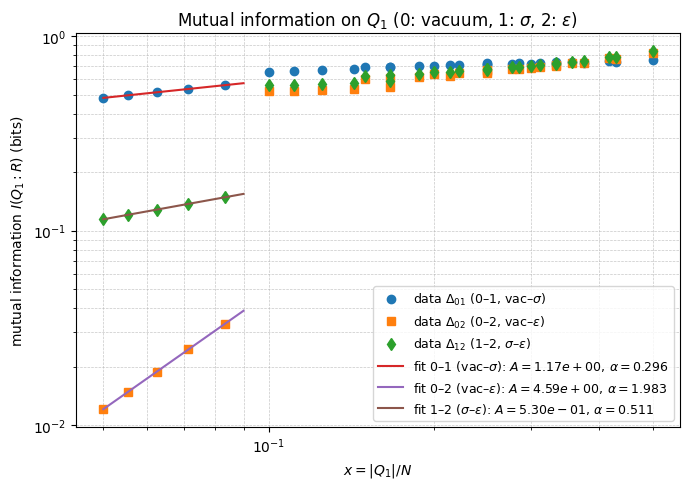

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def power_law_fit(x, y):
    """
    Fit y ~ A * x^alpha using linear regression on log-log data.
    Returns (A, alpha).
    """
    x = np.asarray(x)
    y = np.asarray(y)
    mask = (x > 0) & (y > 0)
    x = x[mask]
    y = y[mask]

    logx = np.log(x)
    logy = np.log(y)

    # Linear fit: log y = log A + alpha * log x
    A_mat = np.vstack([np.ones_like(logx), logx]).T
    beta, alpha = np.linalg.lstsq(A_mat, logy, rcond=None)[0]
    A = np.exp(beta)
    return A, alpha


# -----------------------------
# 1. Hard-code all MI data
# -----------------------------
# Columns: N, x, I01, I02, I12
# 0 = vacuum, 1 = sigma, 2 = epsilon
rows = [
    # N = 12
    (12, 0.083333, 5.6058377931e-01, 3.3238277647e-02, 1.4960006638e-01),
    (12, 0.166667, 6.9508322404e-01, 5.4658769041e-01, 5.8792391361e-01),
    (12, 0.250000, 7.2714558586e-01, 6.4771732327e-01, 6.7340759109e-01),
    (12, 0.333333, 7.3932542882e-01, 7.1265553240e-01, 7.3121727462e-01),
    (12, 0.416667, 7.4747980810e-01, 7.6846476004e-01, 7.8565228125e-01),
    (12, 0.500000, 7.5507962358e-01, 8.1662838772e-01, 8.3719930180e-01),

    # N = 14
    (14, 0.071429, 5.3543557739e-01, 2.4506926538e-02, 1.3665566445e-01),
    (14, 0.142857, 6.8173409535e-01, 5.3618779062e-01, 5.7611734036e-01),
    (14, 0.214286, 7.1511094687e-01, 6.2745256349e-01, 6.5300552169e-01),
    (14, 0.285714, 7.2709714184e-01, 6.8004334274e-01, 6.9847135350e-01),
    (14, 0.357143, 7.3420392399e-01, 7.2405476392e-01, 7.3939548699e-01),
    (14, 0.428571, 7.3988222479e-01, 7.6345344380e-01, 7.7905238393e-01),

    # N = 16
    (16, 0.062500, 5.1465692476e-01, 1.8806827935e-02, 1.2746939675e-01),
    (16, 0.125000, 6.7126420967e-01, 5.2980842233e-01, 5.6833336981e-01),
    (16, 0.187500, 7.0592092689e-01, 6.1547172147e-01, 6.4062315784e-01),
    (16, 0.250000, 7.1805779454e-01, 6.6051641578e-01, 6.7886761480e-01),
    (16, 0.312500, 7.2477321478e-01, 6.9642100064e-01, 7.1111038412e-01),
    (16, 0.375000, 7.2960251483e-01, 7.2866159945e-01, 7.4208935060e-01),

    # N = 18
    (18, 0.055556, 4.9706746450e-01, 1.4885315951e-02, 1.2057124798e-01),
    (18, 0.111111, 6.6276312268e-01, 5.2559599099e-01, 5.6279074846e-01),
    (18, 0.166667, 6.9859696724e-01, 6.0787469751e-01, 6.3252107849e-01),
    (18, 0.222222, 7.1101587697e-01, 6.4815950517e-01, 6.6638938103e-01),
    (18, 0.277778, 7.1761817339e-01, 6.7854568660e-01, 6.9297791748e-01),
    (18, 0.333333, 7.2205660324e-01, 7.0538621115e-01, 7.1785313182e-01),

    # N = 20
    (20, 0.050000, 4.8190080535e-01, 1.2069882849e-02, 1.1518678756e-01),
    (20, 0.100000, 6.5569755293e-01, 5.2272810575e-01, 5.5870182123e-01),
    (20, 0.150000, 6.9260641248e-01, 6.0285244740e-01, 6.2694816793e-01),
    (20, 0.200000, 7.0534706452e-01, 6.4002425626e-01, 6.5804719859e-01),
    (20, 0.250000, 7.1198032105e-01, 6.6662025801e-01, 6.8090393328e-01),
    (20, 0.300000, 7.1623817904e-01, 6.8945542847e-01, 7.0148709409e-01),
]

rows = np.array(rows)
N_all   = rows[:, 0]
x_all   = rows[:, 1]
I01_all = rows[:, 2]  # I(Q1:R) for pair (0,1): vacuum–sigma
I02_all = rows[:, 3]  # I(Q1:R) for pair (0,2): vacuum–epsilon
I12_all = rows[:, 4]  # I(Q1:R) for pair (1,2): sigma–epsilon


# -----------------------------------------
# 2. Choose small-x window for power-law fit
# -----------------------------------------
# Use the “small interval” regime; adjust x_max_fit if desired.
x_max_fit = 0.09
x_min_fit = 0.0
fit_mask = (x_min_fit < x_all) & (x_all <= x_max_fit)

x_fit   = x_all[fit_mask]
I01_fit = I01_all[fit_mask]
I02_fit = I02_all[fit_mask]
I12_fit = I12_all[fit_mask]

# -----------------------------------------
# 3. Do the power-law fits on small-x data
# -----------------------------------------
A01, alpha01 = power_law_fit(x_fit, I01_fit)  # (0,1): vacuum–sigma
A02, alpha02 = power_law_fit(x_fit, I02_fit)  # (0,2): vacuum–epsilon
A12, alpha12 = power_law_fit(x_fit, I12_fit)  # (1,2): sigma–epsilon

print("Power-law fits I(x) ≈ A x^alpha (using x <= {:.3f})".format(x_max_fit))
print("I_01 (vacuum–sigma):   A = {:.6e}, alpha = {:.6f}".format(A01, alpha01))
print("I_02 (vacuum–epsilon): A = {:.6e}, alpha = {:.6f}".format(A02, alpha02))
print("I_12 (sigma–epsilon):  A = {:.6e}, alpha = {:.6f}".format(A12, alpha12))

# -----------------------------------------
# 4. Make log-log plot with fits and labels
# -----------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

# Data points (all N)
ax.loglog(x_all, I01_all, "o",
          label=r"data $\Delta_{01}$ (0–1, vac–$\sigma$)")
ax.loglog(x_all, I02_all, "s",
          label=r"data $\Delta_{02}$ (0–2, vac–$\varepsilon$)")
ax.loglog(x_all, I12_all, "d",
          label=r"data $\Delta_{12}$ (1–2, $\sigma$–$\varepsilon$)")
# Smooth x-range for plotting the fits (only in small-x window)
x_min_plot = x_all.min()
x_max_plot = x_max_fit
x_line = np.logspace(np.log10(x_min_plot), np.log10(x_max_plot), 200)

y01_line = A01 * x_line**alpha01
y02_line = A02 * x_line**alpha02
y12_line = A12 * x_line**alpha12

# Fit curves with A, alpha in legend
lbl01_fit = r"fit 0–1 (vac–$\sigma$): $A={:.2e},\, \alpha={:.3f}$".format(A01, alpha01)
lbl02_fit = r"fit 0–2 (vac–$\varepsilon$): $A={:.2e},\, \alpha={:.3f}$".format(A02, alpha02)
lbl12_fit = r"fit 1–2 ($\sigma$–$\varepsilon$): $A={:.2e},\, \alpha={:.3f}$".format(A12, alpha12)

ax.loglog(x_line, y01_line, "-", label=lbl01_fit)
ax.loglog(x_line, y02_line, "-", label=lbl02_fit)
ax.loglog(x_line, y12_line, "-", label=lbl12_fit)

ax.set_xlabel(r"$x = |Q_1|/N$")
ax.set_ylabel(r"mutual information $I(Q_1 : R)$ (bits)")
ax.set_title(r"Mutual information on $Q_1$ (0: vacuum, 1: $\sigma$, 2: $\varepsilon$)")
ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
ax.legend(fontsize=9, loc="best")

plt.tight_layout()
plt.show()
